In [168]:
# ─────────────────────────────────────────────
# [C1] ◀ Part 0 · ⚙️ 환경 설정과 실습 데이터 환경 준비 — 라이브러리 + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
!pip install scikit-learn xgboost matplotlib seaborn -q
import platform, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

import matplotlib.font_manager as fm

# 한글 폰트 설정 — 그래프의 한글이 □□□로 깨지지 않게 합니다
system = platform.system()
if system == "Darwin":                      # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                                        # 코랩 등 리눅스 — 나눔고딕을 설치해야 합니다
    if not any("Nanum" in f.name for f in fm.fontManager.ttflist):
        print("나눔고딕을 설치합니다 (10~20초 걸립니다)...")
        import subprocess
        subprocess.run("apt-get install -y -qq fonts-nanum", shell=True,
                       capture_output=True)
        for path in fm.findSystemFonts(fontpaths=["/usr/share/fonts/truetype/nanum"]):
            fm.fontManager.addfont(path)
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font=plt.rcParams["font.family"])

import sklearn, xgboost
print("준비 완료 ✓")
print(f"- scikit-learn {sklearn.__version__}")
print(f"- xgboost      {xgboost.__version__}")

준비 완료 ✓
- scikit-learn 1.9.0
- xgboost      3.4.0


In [169]:
# ─────────────────────────────────────────────
# [C1] ◀ Part 0 · ⚙️ 환경 설정과 실습 데이터 데이터 로드 — 분류(유방암) + 회귀(당뇨), 전부 sklearn 내장 (인터넷 불필요)
# ─────────────────────────────────────────────
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 메인 분류 데이터: 유방암 진단 (이진분류) — 🎬 오늘의 무대에서 소개한 공개 실습 데이터
cancer = load_breast_cancer(as_frame=True)
Xc, yc = cancer.data, cancer.target
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    Xc, yc, test_size=0.25, random_state=RANDOM_STATE, stratify=yc)

print(f"분류 데이터(유방암): 학습 {Xc_tr.shape[0]} / 테스트 {Xc_te.shape[0]} | 피처 {Xc.shape[1]}개")
print(f"  클래스: {dict(zip(['악성(0)','양성(1)'], np.bincount(yc)))}")

분류 데이터(유방암): 학습 426 / 테스트 143 | 피처 30개
  클래스: {'악성(0)': np.int64(212), '양성(1)': np.int64(357)}


In [170]:
# ─────────────────────────────────────────────
# [C2] Part 0 · ⚙️ 환경 설정과 실습 데이터
# 데이터 로드와 분할 — 지난 시간과 동일 (실행하면 크기와 클래스 비율이 나옵니다)
# ─────────────────────────────────────────────
X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f"전체 {X.shape[0]}명 × 피처 {X.shape[1]}개")
print(f"  양성(1) 비율 {y.mean():.3f}   ← 비교적 균형 잡힌 데이터입니다")
print()
print(f"학습 {len(X_train)}명 / 테스트 {len(X_test)}명")
print(f"  학습 양성 비율 {y_train.mean():.3f} / 테스트 양성 비율 {y_test.mean():.3f}")
print()
print("→ stratify=y 덕분에 두 쪽의 클래스 비율이 거의 같습니다.")
print("  이 옵션이 왜 중요한지는 Part 4에서 정면으로 다룹니다.")

전체 569명 × 피처 30개
  양성(1) 비율 0.627   ← 비교적 균형 잡힌 데이터입니다

학습 455명 / 테스트 114명
  학습 양성 비율 0.626 / 테스트 양성 비율 0.632

→ stratify=y 덕분에 두 쪽의 클래스 비율이 거의 같습니다.
  이 옵션이 왜 중요한지는 Part 4에서 정면으로 다룹니다.


In [171]:
# ─────────────────────────────────────────────
# [C3] Part 1 · 📊 데이터로 확인해 봅시다 — 시드만 바꿔 열 번
# random_state만 0~9로 바꿔 같은 실험 반복 (실행하면 열 개의 점수와 폭이 나옵니다)
# ─────────────────────────────────────────────
scores_holdout = []
for seed in range(10):
    Xa, Xb, ya, yb = train_test_split(
        X, y, test_size=0.25, random_state=seed, stratify=y)
    m = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    ).fit(Xa, ya)
    scores_holdout.append(m.score(Xb, yb))

scores_holdout = np.array(scores_holdout)

print("random_state별 테스트 정확도")
for seed, s in enumerate(scores_holdout):
    bar = "█" * int((s - 0.95) * 400)      # 0.95를 기준으로 확대해 차이를 보이게
    print(f"  seed={seed}  {s:.3f}  {bar}")
print()
print(f"최소 {scores_holdout.min():.3f} / 최대 {scores_holdout.max():.3f}"
      f" → 폭 {scores_holdout.max() - scores_holdout.min():.3f}")
print(f"평균 {scores_holdout.mean():.3f} ± {scores_holdout.std():.3f}")
print()
print("→ 모델도 데이터도 똑같습니다. 바꾼 것은 '어떻게 나눌지'뿐입니다.")

random_state별 테스트 정확도
  seed=0  0.958  ███
  seed=1  0.965  ██████
  seed=2  0.972  ████████
  seed=3  0.986  ██████████████
  seed=4  0.972  ████████
  seed=5  0.979  ███████████
  seed=6  0.993  █████████████████
  seed=7  0.979  ███████████
  seed=8  0.972  ████████
  seed=9  0.979  ███████████

최소 0.958 / 최대 0.993 → 폭 0.035
평균 0.976 ± 0.010

→ 모델도 데이터도 똑같습니다. 바꾼 것은 '어떻게 나눌지'뿐입니다.


여기서 중요한 사실 하나 — 0.993을 보고하고 싶은 유혹이 생깁니다. 
여러 시드를 확인한 뒤 가장 높은 점수만 선택해 보고하면, 그 선택 과정 자체가 점수를 낙관적으로 보이게 만듭니다. 이런 관행을 체리피킹이라고 합니다. (자신에게 유리한 것만 선택해내는 행동)

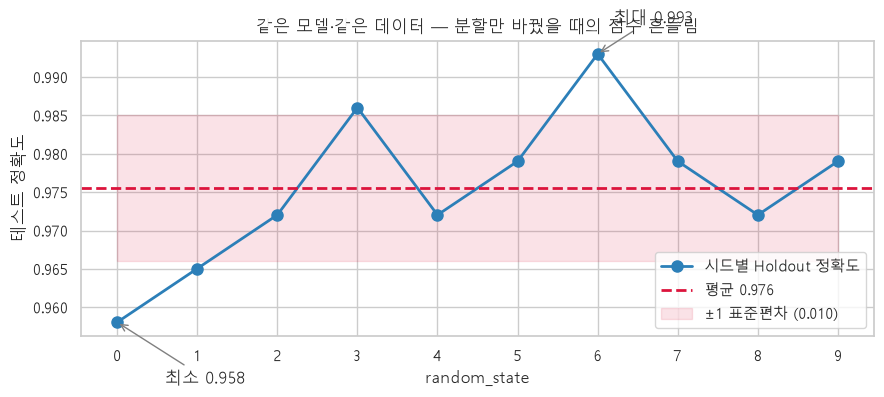

→ 붉은 띠(±1 표준편차) 밖으로 점이 튀어나가는 것을 보세요. 한 점만 보고하면 그 점이 어디였는지에 운이 좌우합니다.


In [172]:
# ─────────────────────────────────────────────
# [C4] Part 1 · 📊 데이터로 확인해 봅시다 — 시드만 바꿔 열 번
# 흔들림을 그림으로 — 점수 분포와 평균±표준편차 (실행하면 그래프가 그려집니다)
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.2))

ax.plot(range(10), scores_holdout, "o-", lw=2, markersize=8,
        color="#2c7fb8", label="시드별 Holdout 정확도")
mean_, std_ = scores_holdout.mean(), scores_holdout.std()
ax.axhline(mean_, color="crimson", ls="--", lw=2, label=f"평균 {mean_:.3f}")
ax.fill_between(range(10), mean_ - std_, mean_ + std_, color="crimson", alpha=0.12,
                label=f"±1 표준편차 ({std_:.3f})")
ax.annotate(f"최대 {scores_holdout.max():.3f}",
            xy=(int(np.argmax(scores_holdout)), scores_holdout.max()),
            xytext=(6.2, scores_holdout.max() + 0.004),
            arrowprops=dict(arrowstyle="->", color="gray"))
ax.annotate(f"최소 {scores_holdout.min():.3f}",
            xy=(int(np.argmin(scores_holdout)), scores_holdout.min()),
            xytext=(0.6, scores_holdout.min() - 0.008),
            arrowprops=dict(arrowstyle="->", color="gray"))

ax.set_xlabel("random_state")
ax.set_ylabel("테스트 정확도")
ax.set_title("같은 모델·같은 데이터 — 분할만 바꿨을 때의 점수 흔들림")
ax.set_xticks(range(10))
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("→ 붉은 띠(±1 표준편차) 밖으로 점이 튀어나가는 것을 보세요. 한 점만 보고하면 그 점이 어디였는지에 운이 좌우합니다.")

파란 점들이 시드별 점수이고, 붉은 점선이 평균, 붉은 띠가 ±1 표준편차 구간입니다. 점들이 띠 안에 대체로 머물지만 위아래로 튀어나가는 것이 보입니다.

[문제]
[C3]과 같은 실험을 test_size만 바꿔 반복해보세요.

(1) test_size=0.5 (테스트 세트를 절반으로 크게)로 시드 0~9를 돌려
   점수의 폭(최대-최소)과 표준편차를 구해보세요.
2) test_size=0.1 (테스트 세트를 아주 작게)로 같은 것을 구해보세요.
3) 두 결과를 비교하면, 테스트 세트 크기와 점수 흔들림은 어떤 관계입니까?

In [173]:
scores_holdout = []
for seed in range(10):
    Xa, Xb, ya, yb = train_test_split(
        X, y, test_size=0.5, random_state=seed, stratify=y)
    m = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    ).fit(Xa, ya)
    scores_holdout.append(m.score(Xb, yb))

scores_holdout = np.array(scores_holdout)

print("test_size=0.5일 때 random_state별 테스트 정확도")
for seed, s in enumerate(scores_holdout):
    bar = "█" * int((s - 0.95) * 400)      # 0.95를 기준으로 확대해 차이를 보이게
    print(f"  seed={seed}  {s:.3f}  {bar}")
print()
print(f"최소 {scores_holdout.min():.3f} / 최대 {scores_holdout.max():.3f}"
      f" → 폭 {scores_holdout.max() - scores_holdout.min():.3f}")
print(f"평균 {scores_holdout.mean():.3f} ± {scores_holdout.std():.3f}")
print()

test_size=0.5일 때 random_state별 테스트 정확도
  seed=0  0.979  ███████████
  seed=1  0.972  ████████
  seed=2  0.972  ████████
  seed=3  0.979  ███████████
  seed=4  0.979  ███████████
  seed=5  0.965  █████
  seed=6  0.972  ████████
  seed=7  0.968  ███████
  seed=8  0.975  ██████████
  seed=9  0.986  ██████████████

최소 0.965 / 최대 0.986 → 폭 0.021
평균 0.975 ± 0.006



In [174]:
scores_holdout = []
for seed in range(10):
    Xa, Xb, ya, yb = train_test_split(
        X, y, test_size=0.1, random_state=seed, stratify=y)
    m = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    ).fit(Xa, ya)
    scores_holdout.append(m.score(Xb, yb))

scores_holdout = np.array(scores_holdout)

print("test_size=0.1일 때 random_state별 테스트 정확도")
for seed, s in enumerate(scores_holdout):
    bar = "█" * int((s - 0.95) * 400)      # 0.95를 기준으로 확대해 차이를 보이게
    print(f"  seed={seed}  {s:.3f}  {bar}")
print()
print(f"최소 {scores_holdout.min():.3f} / 최대 {scores_holdout.max():.3f}"
      f" → 폭 {scores_holdout.max() - scores_holdout.min():.3f}")
print(f"평균 {scores_holdout.mean():.3f} ± {scores_holdout.std():.3f}")
print()

test_size=0.1일 때 random_state별 테스트 정확도
  seed=0  0.982  ████████████
  seed=1  0.982  ████████████
  seed=2  1.000  ████████████████████
  seed=3  0.982  ████████████
  seed=4  1.000  ████████████████████
  seed=5  0.982  ████████████
  seed=6  0.982  ████████████
  seed=7  0.982  ████████████
  seed=8  0.965  █████
  seed=9  1.000  ████████████████████

최소 0.965 / 최대 1.000 → 폭 0.035
평균 0.986 ± 0.011




test_size=0.5일 때 정확도는 평균 0.975 ± 0.006
test_size=0.1일 때 정확도는 평균 0.986 ± 0.011

테스트 사이즈 크기가 작아질수록 점수 흔들림이 커진다.
ex) 테스트 세트가 작으면 한 명을 틀릴 때 정확도가 0.011 작아진다.


한 번의 Holdout 점수에 섞여 있는 두 가지 요소를 말할 수 있습니까?
▸ 학습 세트 / 테스트 세트의 구성 운

0.97 ± 0.01과 0.97 ± 0.15가 어떻게 다른 이야기인지 설명할 수 있습니까?
▸ 전자는 흔들림이 적고, 후자는 흔들림이 많다는 뜻(현재 데이터와 검증 방식에서 결과가 민감하다는 신호)

여러 시드를 돌려보고 가장 높은 점수만 보고하는 것이 왜 문제입니까?
▸  여러 시드를 확인한 뒤 가장 높은 점수만 선택해 보고하면, 그 선택 과정 자체가 점수를 낙관적으로 보이게 만듭니다. 새 데이터에서 같은 결과가 나올 것이라고 기대하기 어렵습니다. 이런 관행을 체리피킹이라고 합니다.


In [175]:
# ─────────────────────────────────────────────
# [C6] Part 2 · 📊 데이터로 확인해 봅시다 — 과적합이 태어나는 장면
# 트리 깊이를 키우며 학습/테스트 점수 추적 (실행하면 깊이별 격차 표가 나옵니다)
# ─────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier

depths = [1, 2, 3, 5, 8, 12, None]

rows = []
for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    tree.fit(X_train, y_train)
    tr = tree.score(X_train, y_train)
    te = tree.score(X_test, y_test)
    rows.append({
        "max_depth": "제한 없음" if d is None else d,
        "학습 점수": tr,
        "테스트 점수": te,
        "격차": tr - te,
        "실제 깊이": tree.get_depth(),
    })
gap = pd.DataFrame(rows)
print(gap.round(3).to_string(index=False))
print()
best = gap.loc[gap["테스트 점수"].idxmax()]
print(f"→ 테스트 점수가 가장 높은 설정: max_depth={best['max_depth']} (테스트 {best['테스트 점수']:.3f})")
print(f"  학습 점수가 1.000이 되는 지점부터 테스트는 {gap['테스트 점수'].iloc[-1]:.3f}에 머물고 격차만 벌어집니다.")

max_depth  학습 점수  테스트 점수    격차  실제 깊이
        1  0.923   0.921 0.002      1
        2  0.958   0.895 0.064      2
        3  0.976   0.939 0.037      3
        5  0.993   0.921 0.072      5
        8  1.000   0.912 0.088      7
       12  1.000   0.912 0.088      7
    제한 없음  1.000   0.912 0.088      7

→ 테스트 점수가 가장 높은 설정: max_depth=3 (테스트 0.939)
  학습 점수가 1.000이 되는 지점부터 테스트는 0.912에 머물고 격차만 벌어집니다.


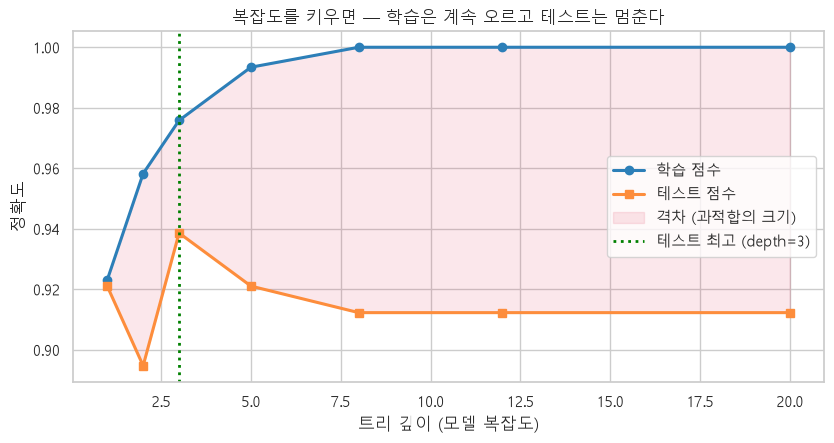

→ 붉은 영역이 넓어지는 것이 곧 과적합이 자라는 모습입니다.
  녹색 점선 왼쪽은 과소적합 영역, 오른쪽은 과적합 영역입니다.


In [176]:
# ─────────────────────────────────────────────
# [C7] Part 2 · 📊 데이터로 확인해 봅시다 — 과적합이 태어나는 장면
# 격차가 벌어지는 모습을 그림으로 (실행하면 두 곡선과 격차 영역이 그려집니다)
# ─────────────────────────────────────────────
plot_depths = [1, 2, 3, 5, 8, 12, 20]
tr_scores, te_scores = [], []
for d in plot_depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE).fit(X_train, y_train)
    tr_scores.append(t.score(X_train, y_train))
    te_scores.append(t.score(X_test, y_test))

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.plot(plot_depths, tr_scores, "o-", lw=2.2, color="#2c7fb8", label="학습 점수")
ax.plot(plot_depths, te_scores, "s-", lw=2.2, color="#fd8d3c", label="테스트 점수")
ax.fill_between(plot_depths, te_scores, tr_scores, color="crimson", alpha=0.10,
                label="격차 (과적합의 크기)")
best_i = int(np.argmax(te_scores))
ax.axvline(plot_depths[best_i], color="green", ls=":", lw=2,
           label=f"테스트 최고 (depth={plot_depths[best_i]})")
ax.set_xlabel("트리 깊이 (모델 복잡도)")
ax.set_ylabel("정확도")
ax.set_title("복잡도를 키우면 — 학습은 계속 오르고 테스트는 멈춘다")
ax.legend(loc="center right")
plt.tight_layout()
plt.show()

print("→ 붉은 영역이 넓어지는 것이 곧 과적합이 자라는 모습입니다.")
print(f"  녹색 점선 왼쪽은 과소적합 영역, 오른쪽은 과적합 영역입니다.")

[문제]
[C6]에서 트리 깊이로 과적합을 봤습니다. 이번엔 다른 손잡이를 써보세요.

1) DecisionTreeClassifier의 min_samples_leaf를 1, 5, 10, 30, 50으로 바꿔가며
   학습 점수·테스트 점수·격차를 표로 출력해보세요. (max_depth는 주지 마세요)
2) 격차가 가장 작은 설정과 테스트 점수가 가장 높은 설정을 각각 찾아보세요.
   두 설정이 같습니까?
3) min_samples_leaf를 키우는 것이 왜 과적합을 억제하는지 한 줄로 설명해보세요.

In [177]:
min_samples_leaf = [1, 2, 3, 5, 8, 12, 20]
rows=[]
for n in min_samples_leaf:
    tree = DecisionTreeClassifier(min_samples_leaf=n, random_state=RANDOM_STATE)
    tree.fit(X_train, y_train)
    tr = tree.score(X_train, y_train)
    te = tree.score(X_test, y_test)
    rows.append({
        "min_samples_leaf": n,
        "학습 점수": tr,
        "테스트 점수": te,
        "격차": tr - te,
        "실제 깊이": tree.get_depth(),
    })
gap = pd.DataFrame(rows)
print(gap.round(3).to_string(index=False))
print()

 min_samples_leaf  학습 점수  테스트 점수    격차  실제 깊이
                1  1.000   0.912 0.088      7
                2  0.991   0.877 0.114      6
                3  0.980   0.912 0.068      6
                5  0.976   0.930 0.046      6
                8  0.963   0.947 0.015      6
               12  0.963   0.947 0.015      5
               20  0.947   0.904 0.044      4



In [178]:
print("\n격차가 가장 작은 설정")
gap.loc[gap["격차"].idxmin()]


격차가 가장 작은 설정


min_samples_leaf    8.000000
학습 점수               0.962637
테스트 점수              0.947368
격차                  0.015269
실제 깊이               6.000000
Name: 4, dtype: float64

In [179]:
print("\n테스트 점수가 가장 높은 설정")
gap.loc[gap["테스트 점수"].idxmax()]


테스트 점수가 가장 높은 설정


min_samples_leaf    8.000000
학습 점수               0.962637
테스트 점수              0.947368
격차                  0.015269
실제 깊이               6.000000
Name: 4, dtype: float64

3) min_samples_leaf를 키우는 것이 왜 과적합을 억제하는지 한 줄로 설명해보세요.
- "잎 하나에 최소 있어야 하는 표본의 수가 늘어나므로 잎의 깊이가 깊어지지 않음. 즉 모델이 과하게 복잡해지는 것을 억제

In [180]:
# ─────────────────────────────────────────────
# [C11] Part 3 · 📊 데이터로 확인해 봅시다 — 우리 데이터는 어느 구간인가
# 학습곡선 계산 — 데이터 양을 늘려가며 학습/검증 점수 (실행하면 단계별 표가 나옵니다)
# ─────────────────────────────────────────────
from sklearn.model_selection import learning_curve
from sklearn.model_selection import StratifiedKFold

model_lc = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
)
train_sizes, train_scores, val_scores = learning_curve(
    model_lc, X, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    train_sizes=np.linspace(0.1, 1.0, 6),
    scoring="accuracy",
)

lc = pd.DataFrame({
    "학습 표본 수": train_sizes.astype(int),
    "학습 점수": train_scores.mean(axis=1),
    "검증 점수": val_scores.mean(axis=1),
})
lc["격차"] = lc["학습 점수"] - lc["검증 점수"]
lc["검증 점수 증가분"] = lc["검증 점수"].diff().fillna(0)

print(lc.round(3).to_string(index=False))
print()
last_gain = lc["검증 점수 증가분"].iloc[-1]
print(f"→ 마지막 구간(표본 {int(train_sizes[-2])}→{int(train_sizes[-1])})의 검증 점수 변화: {last_gain:+.3f}")
print("  이 값이 0에 가까우면 '데이터를 더 모아도 이득이 거의 없다'는 신호입니다.")

 학습 표본 수  학습 점수  검증 점수    격차  검증 점수 증가분
      45  0.987  0.859 0.127      0.000
     127  0.983  0.954 0.028      0.095
     209  0.987  0.970 0.016      0.016
     291  0.982  0.967 0.015     -0.004
     373  0.987  0.977 0.010      0.011
     455  0.988  0.974 0.014     -0.004

→ 마지막 구간(표본 373→455)의 검증 점수 변화: -0.004
  이 값이 0에 가까우면 '데이터를 더 모아도 이득이 거의 없다'는 신호입니다.


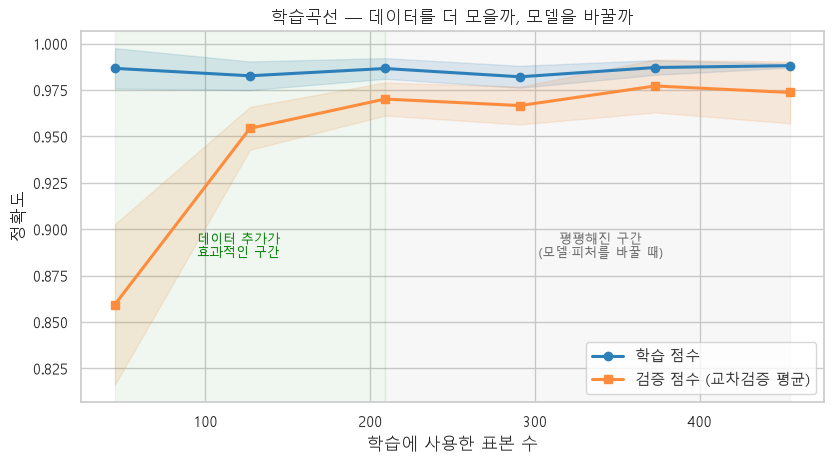

→ 주황 선(검증)의 오른쪽 끝이 평평하면 데이터 추가의 이득이 거의 없다는 뜻입니다.


In [181]:
# ─────────────────────────────────────────────
# [C12] Part 3 · 📊 데이터로 확인해 봅시다 — 우리 데이터는 어느 구간인가
# 학습곡선 그리기 — 흔들림 범위까지 함께 (실행하면 두 곡선과 신뢰 띠가 그려집니다)
# ─────────────────────────────────────────────
tr_mean, tr_std = train_scores.mean(axis=1), train_scores.std(axis=1)
va_mean, va_std = val_scores.mean(axis=1), val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(train_sizes, tr_mean, "o-", lw=2.2, color="#2c7fb8", label="학습 점수")
ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, color="#2c7fb8", alpha=0.15)
ax.plot(train_sizes, va_mean, "s-", lw=2.2, color="#fd8d3c", label="검증 점수 (교차검증 평균)")
ax.fill_between(train_sizes, va_mean - va_std, va_mean + va_std, color="#fd8d3c", alpha=0.15)

ax.axvspan(train_sizes[0], 209, color="green", alpha=0.06)
ax.text(120, 0.885, "데이터 추가가\n효과적인 구간", ha="center", fontsize=9, color="green")
ax.axvspan(209, train_sizes[-1], color="gray", alpha=0.06)
ax.text(340, 0.885, "평평해진 구간\n(모델·피처를 바꿀 때)", ha="center", fontsize=9, color="dimgray")

ax.set_xlabel("학습에 사용한 표본 수")
ax.set_ylabel("정확도")
ax.set_title("학습곡선 — 데이터를 더 모을까, 모델을 바꿀까")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("→ 주황 선(검증)의 오른쪽 끝이 평평하면 데이터 추가의 이득이 거의 없다는 뜻입니다.")

그래서 판단은 이렇습니다 — "환자 데이터를 더 모으자"는 제안에는 반대

(검증점수의 변화가 209명 이후로 거의 변하지 않음으로)
200명 수준에서 이미 이 모델의 한계에 도달했고, 300명을 더 모아도 검증 점수는 0.98 근처에 머물 것입니다. 성능을 더 올리려면 데이터 양이 아니라 다른 것을 바꿔야 합니다 — 새로운 종류의 피처, 더 표현력 있는 모델, 또는 문제 정의 자체입니다.

[문제]
[C11]은 로지스틱 회귀의 학습곡선이었습니다. 이번엔 과적합이 심한 모델로 그려보세요.

1) DecisionTreeClassifier(random_state=RANDOM_STATE)로 같은 학습곡선을 계산해 학습 점수·검증 점수·격차를 표로 출력해보세요.
2) 로지스틱 회귀의 곡선과 비교하면, 격차의 크기가 어떻게 다릅니까? 로지스틱보다 의사결정나무의 격차가 크다. 
3) 이 트리 모델에 대해서는 "데이터를 더 모으자"와 "모델을 바꾸자" 중
   어느 쪽을 권해야 할까요? 근거를 한 줄로 적어보세요. 모델을 바꾸는 게 나음. 로지스틱과 동일하게 200명 수준에서 이미 이 모델의 한계에 도달했고, 300명을 더 모아도 검증 점수는 0.98 근처에 머물 것입니다. 성능을 더 올리려면 데이터 양이 아니라 다른 것을 바꿔야 합니다 — 새로운 종류의 피처, 더 표현력 있는 모델, 또는 문제 정의 자체

In [182]:
model_lcd = DecisionTreeClassifier(random_state=RANDOM_STATE)
train_sizes, train_scores, val_scores = learning_curve(
    model_lcd, X, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    train_sizes=np.linspace(0.1, 1.0, 6),
    scoring="accuracy",
)
lc = pd.DataFrame({
    "학습 표본 수": train_sizes.astype(int),
    "학습 점수": train_scores.mean(axis=1),
    "검증 점수": val_scores.mean(axis=1),
})
lc["격차"] = lc["학습 점수"] - lc["검증 점수"]
lc["검증 점수 증가분"] = lc["검증 점수"].diff().fillna(0)
print(lc.round(3).to_string(index=False))
print()

 학습 표본 수  학습 점수  검증 점수    격차  검증 점수 증가분
      45    1.0  0.810 0.190      0.000
     127    1.0  0.877 0.123      0.067
     209    1.0  0.910 0.090      0.033
     291    1.0  0.896 0.104     -0.014
     373    1.0  0.909 0.091      0.012
     455    1.0  0.910 0.090      0.002



In [183]:
# ─────────────────────────────────────────────
# [C14] Part 4 · 📊 데이터로 확인해 봅시다 — 조각의 구성을 직접 들여다보기
# 세 가지 분할 방식의 fold별 클래스 비율 비교 (실행하면 조각별 양성 비율이 나옵니다)
# ─────────────────────────────────────────────
from sklearn.model_selection import KFold
splitters = [
    ("KFold (셔플 없음) 조각 ", KFold(n_splits=5)),
    ("KFold (shuffle=True) 셔플 + 조각 ", KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)),
    ("StratifiedKFold (shuffle=True) 클래스 비율을 전체와 같게 + 조각 ",
     StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)),
]

print(f"전체 양성 비율 = {y.mean():.3f}\n")
for name, sp in splitters:
    rates = [y[val_idx].mean() for _, val_idx in sp.split(X, y)]
    print(f"{name}")
    print(f"  조각별 양성 비율 {[round(float(r), 3) for r in rates]}")
    print(f"  → 최대-최소 폭 {max(rates) - min(rates):.3f}")
    print()

전체 양성 비율 = 0.627

KFold (셔플 없음) 조각 
  조각별 양성 비율 [0.404, 0.57, 0.649, 0.746, 0.77]
  → 최대-최소 폭 0.366

KFold (shuffle=True) 셔플 + 조각 
  조각별 양성 비율 [0.623, 0.675, 0.623, 0.623, 0.593]
  → 최대-최소 폭 0.083

StratifiedKFold (shuffle=True) 클래스 비율을 전체와 같게 + 조각 
  조각별 양성 비율 [0.623, 0.623, 0.632, 0.632, 0.628]
  → 최대-최소 폭 0.009



In [184]:
# ─────────────────────────────────────────────
# [C15] Part 4 · 📊 데이터로 확인해 봅시다 — 조각의 구성을 직접 들여다보기
# 분할 방식이 실제 점수에 미치는 영향 + 다중 지표 동시 교차검증
# (실행하면 방식별 점수와 지표 5종이 나옵니다)
# ─────────────────────────────────────────────
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score

print("① 분할 방식이 최종 점수를 얼마나 바꾸나")
for name, sp in splitters:
    s = cross_val_score(model_lc, X, y, cv=sp, scoring="accuracy")
    print(f"  {name:32} {s.mean():.4f} ± {s.std():.4f}")

print()
print("② 한 번에 여러 지표로 교차검증 (StratifiedKFold 5겹)")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
result = cross_validate(model_lc, X, y, cv=cv,
                        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"])

rows = []
for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    arr = result["test_" + metric]
    rows.append({"지표": metric, "평균": arr.mean(), "표준편차": arr.std(),
                 "보고 형식": f"{arr.mean():.3f} ± {arr.std():.3f}"})
multi = pd.DataFrame(rows)
print(multi.round(4).to_string(index=False))

① 분할 방식이 최종 점수를 얼마나 바꾸나
  KFold (셔플 없음) 조각                 0.9772 ± 0.0119
  KFold (shuffle=True) 셔플 + 조각     0.9771 ± 0.0090
  StratifiedKFold (shuffle=True) 클래스 비율을 전체와 같게 + 조각  0.9737 ± 0.0166

② 한 번에 여러 지표로 교차검증 (StratifiedKFold 5겹)
       지표     평균   표준편차         보고 형식
 accuracy 0.9737 0.0166 0.974 ± 0.017
precision 0.9683 0.0290 0.968 ± 0.029
   recall 0.9916 0.0112 0.992 ± 0.011
       f1 0.9794 0.0127 0.979 ± 0.013
  roc_auc 0.9953 0.0053 0.995 ± 0.005


In [185]:
# ─────────────────────────────────────────────
# [C16] Part 4 · 데이터로 확인 — 지난 시간 모델들을 다시 채점하기
# Holdout 1회 vs 계층 5겹 CV — 순서 2 모델 4종 재추정 (실행하면 비교표가 나옵니다)
# ─────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.dummy import DummyClassifier

candidates = {
    "LogisticRegression": make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
    "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=3,
                             random_state=RANDOM_STATE, eval_metric="logloss"),
}

# 베이스라인도 함께 — "이보다 나아야 모델"
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
print(f"베이스라인(다수 클래스 찍기) 정확도 = {dummy.score(X_test, y_test):.4f}\n")

rows = []
for name, m in candidates.items():
    m.fit(X_train, y_train)
    holdout = m.score(X_test, y_test)
    cv_scores = cross_val_score(m, X, y, cv=cv, scoring="accuracy")
    rows.append({
        "모델": name,
        "Holdout 1회": holdout,
        "CV 평균": cv_scores.mean(),
        "CV 표준편차": cv_scores.std(),
        "CV 보고 형식": f"{cv_scores.mean():.3f} ± {cv_scores.std():.3f}",
        "Holdout − CV": holdout - cv_scores.mean(),
    })
compare = pd.DataFrame(rows)
print(compare.round(4).to_string(index=False))
print()
print(f"Holdout 기준 1위: {compare.loc[compare['Holdout 1회'].idxmax(), '모델']}")
print(f"CV 기준 1위:      {compare.loc[compare['CV 평균'].idxmax(), '모델']}")
print(f"가장 불안정한 모델: {compare.loc[compare['CV 표준편차'].idxmax(), '모델']}"
      f" (± {compare['CV 표준편차'].max():.4f})")

베이스라인(다수 클래스 찍기) 정확도 = 0.6316

                모델  Holdout 1회  CV 평균  CV 표준편차      CV 보고 형식  Holdout − CV
LogisticRegression      0.9825 0.9737   0.0166 0.974 ± 0.017        0.0088
      DecisionTree      0.9123 0.9104   0.0279 0.910 ± 0.028        0.0019
      RandomForest      0.9474 0.9526   0.0131 0.953 ± 0.013       -0.0052
           XGBoost      0.9561 0.9648   0.0157 0.965 ± 0.016       -0.0087

Holdout 기준 1위: LogisticRegression
CV 기준 1위:      LogisticRegression
가장 불안정한 모델: DecisionTree (± 0.0279)


[문제]
겹의 수(k)를 바꾸면 무엇이 달라지는지 직접 확인해보세요.

1) LogisticRegression 파이프라인에 대해 k = 3, 5, 10, 20으로
   StratifiedKFold 교차검증을 돌려 평균과 표준편차를 표로 출력하세요.
2) k가 커질 때 표준편차는 어떻게 변합니까? 점점 커진다.
3) 그 이유를 Part 1의 ⌨️(1) 결과와 연결해 한 줄로 설명해보세요.
테스트 세트가 작을수록 흔들림이 커집니다. 


In [187]:
model_lc = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
)
rowss = []
k_values = [3, 5, 10, 20]
for k in k_values:
    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)
    result = cross_validate(model_lc, X, y, cv=cv, scoring="accuracy")
    rowss.append({
        "k": k,
        "크기": len(X) // k,
        "CV 평균": result["test_score"].mean(),
        "CV 표준편차": result["test_score"].std(),
        "보고 형식": f"{result['test_score'].mean():.3f} ± {result['test_score'].std():.3f}",
    })

compare = pd.DataFrame(rowss)
print(compare.round(4).to_string(index=False))
print()

 k  크기  CV 평균  CV 표준편차         보고 형식
 3 189 0.9754   0.0099 0.975 ± 0.010
 5 113 0.9737   0.0166 0.974 ± 0.017
10  56 0.9754   0.0195 0.975 ± 0.020
20  28 0.9789   0.0282 0.979 ± 0.028



개념 퀴즈

어떤 모델의 학습 정확도가 1.000, 테스트 정확도가 0.85입니다. 진단과 처방을 각각 한 줄로 적어보세요.
▸ 과적합 (분산↑). 복잡도↓, 규제, 데이터↑

동료가 "정확도 0.99를 달성했습니다"라고 보고했습니다. 되물어야 할 질문 두 개를 적어보세요.
▸ 평균은 얼마인가요? 
▸ 표준편차는 얼마인가요?

학습곡선을 그렸더니 검증 곡선이 오른쪽 끝에서 여전히 가파르게 오르고 있었습니다. 무엇을 해야 합니까?
▸ 데이터를 더 모아야 합니다. 

두 모델의 CV 결과가 A: 0.91 ± 0.03, B: 0.90 ± 0.01입니다. 어느 쪽을 택하겠습니까? 근거를 함께 적어보세요.

B. 정확도가 90%가 넘어가면 90%나 91%나 별 차이가 느껴지지 않음.
그러나 표준편차가 0.02, 2% 차이라면 A는 운에 의해 잘 나왔을 가능성도 있기 때문에 B를 택해 분석의 타당성을 높이겠다. 

In [ ]:
# [C18] ❓ 오늘의 퀴즈 · 코드 퀴즈
# 코드 퀴즈 — 빈칸(____)을 채워 CV 평균 ± 표준편차 보고

rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
# quiz_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)   # 분류용 분할기
# scores = cross_val_score(rf, X, y, cv=quiz_cv, scoring="accuracy")               # 교차검증 실행
# print(f"정확도 {scores.mean():.3f} ± {scores.std():.3f}")            # 평균 ± 표준편차

# 여기에 코드를 작성하세요